# AI Business Application Final Project

## AI-Powered Classification and Summarization of Mortgage Servicing Legal Documents

**Student:** Rashee Lott  
**Course:** MIS-571: Artificial Intelligence for Business Applications  
**Instructor:** Dr. Rajan Thapaliya, Ph.D.  
**Module:** Module 6  
**Date:** July 2026

## Project Overview

This notebook demonstrates a machine learning application designed to support mortgage servicing analysts who review county-recorded legal documents. The prototype classifies documents such as mechanic's liens, lis pendens, judgments, tax liens, releases, satisfactions, and mortgage assignments.

The goal is not to replace human analysts. Instead, the system provides an initial classification, confidence score, and business summary so analysts can complete repetitive reviews more efficiently and focus on complex exceptions.

Simulated data is used because real mortgage servicing documents may contain confidential borrower and property information.

## 1. Importing the Required Libraries

This section imports the Python libraries used throughout the project.

- **pandas** organizes the simulated documents in tables.
- **NumPy** supports numerical operations.
- **matplotlib** creates the confusion matrix visualization.
- **scikit-learn** provides the TF-IDF text-processing method, Logistic Regression model, train-test split, and evaluation metrics.
- **re** supports pattern matching for extracting dates, dollar amounts, and property addresses.

A fixed random state is used so the results remain consistent each time the notebook is executed.

In [ ]:
# Import the libraries needed for the project

import re
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# This keeps the results consistent every time the notebook runs
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Creating the Simulated Dataset

This project uses simulated legal-document text rather than actual borrower records. Each simulated document represents a realistic county-recorded instrument that a mortgage servicing analyst may encounter.

The dataset includes eight categories:

1. Mechanic's Lien
2. Lis Pendens
3. Judgment
4. Tax Lien
5. Release
6. Satisfaction
7. Assignment
8. Other

Each category contains 12 documents, resulting in 96 total records. Fictional names, addresses, dates, and dollar amounts are used to protect privacy while still representing a realistic business process.

In [ ]:
# Create a simulated dataset of county-recorded legal documents.
# No real borrower, customer, or account information is used.

templates = {
    "Mechanic's Lien": [
        "NOTICE OF MECHANIC'S LIEN. {claimant} claims a lien in the amount of {amount} "
        "for labor and materials furnished to property located at {address}. "
        "Owner: {owner}. Recorded on {date}.",

        "CONSTRUCTION LIEN CLAIM filed by {claimant} against {owner}. "
        "Unpaid balance {amount}. The improvements concern {address}. "
        "Recording date {date}.",

        "MECHANICS LIEN: Contractor {claimant} states that services remain unpaid "
        "in the sum of {amount}. Subject premises: {address}. "
        "Property owner {owner}. Filed {date}."
    ],

    "Lis Pendens": [
        "NOTICE OF PENDENCY OF ACTION (LIS PENDENS). Plaintiff {claimant} commenced "
        "an action affecting title to real property at {address} against defendant "
        "{owner}. Filed {date}.",

        "LIS PENDENS recorded {date}. Pending litigation may affect the ownership "
        "or title of {address}. Plaintiff: {claimant}. Defendant: {owner}.",

        "NOTICE OF PENDENCY concerning foreclosure litigation against {owner} and "
        "property known as {address}. Action filed by {claimant} on {date}."
    ],

    "Judgment": [
        "JUDGMENT entered in favor of {claimant} and against {owner} in the amount "
        "of {amount}. Docketed {date}. Address reference: {address}.",

        "FINAL JUDGMENT: Debtor {owner} owes creditor {claimant} {amount}. "
        "Judgment recorded on {date} and may attach to real property including "
        "{address}.",

        "CIVIL JUDGMENT filed {date}. Creditor {claimant}; debtor {owner}; "
        "award {amount}. Property indicator: {address}."
    ],

    "Tax Lien": [
        "FEDERAL TAX LIEN against taxpayer {owner} for unpaid taxes totaling "
        "{amount}. Notice filed {date}. Address: {address}.",

        "STATE TAX WARRANT AND LIEN recorded against {owner} in the amount of "
        "{amount}. Filing date {date}. Property address {address}.",

        "MUNICIPAL TAX LIEN for delinquent real estate taxes of {amount} affecting "
        "{address}. Taxpayer {owner}. Recorded {date}."
    ],

    "Release": [
        "RELEASE OF LIEN. {claimant} releases and discharges the lien previously "
        "recorded against {owner} and property at {address}. Executed {date}.",

        "FULL RELEASE: The claimant {claimant} confirms that the prior lien affecting "
        "{address} has been released. Owner {owner}. Date {date}.",

        "DISCHARGE AND RELEASE OF RECORDED LIEN dated {date}. Prior claim by "
        "{claimant} against {owner} concerning {address} is terminated."
    ],

    "Satisfaction": [
        "SATISFACTION OF JUDGMENT. {claimant} acknowledges full payment and "
        "satisfaction of the judgment against {owner}. Filed {date}. "
        "Property reference {address}.",

        "JUDGMENT SATISFIED in full on {date}. Creditor {claimant} releases debtor "
        "{owner} from the judgment associated with {address}.",

        "ACKNOWLEDGMENT OF SATISFACTION: The judgment in favor of {claimant} against "
        "{owner} has been paid. Recorded {date}."
    ],

    "Assignment": [
        "ASSIGNMENT OF MORTGAGE. {claimant} assigns all interest in the mortgage "
        "concerning {address} to {owner}. Assignment executed {date}.",

        "MORTGAGE ASSIGNMENT recorded {date}. Assignor {claimant}; "
        "assignee {owner}; property {address}.",

        "TRANSFER AND ASSIGNMENT of mortgage rights from {claimant} to {owner} "
        "for premises at {address}, effective {date}."
    ],

    "Other": [
        "QUITCLAIM DEED executed {date} conveying interest in {address} from "
        "{claimant} to {owner}.",

        "NOTICE OF CODE VIOLATION issued to {owner} regarding conditions at "
        "{address}. Inspection date {date}.",

        "PROPERTY RECORDING COVER SHEET for instrument submitted by {claimant} "
        "concerning {address} on {date}."
    ]
}

claimants = [
    "Garden State Roofing LLC",
    "Atlantic Supply Company",
    "County of Mercer",
    "First National Bank",
    "United States Treasury",
    "Pine Street Builders"
]

owners = [
    "Jordan Taylor",
    "Morgan Reed",
    "Casey Williams",
    "Avery Johnson",
    "Riley Parker",
    "Cameron Davis"
]

addresses = [
    "101 Oak Street, Trenton, NJ 08608",
    "55 Market Avenue, Camden, NJ 08102",
    "220 Maple Lane, Mount Laurel, NJ 08054",
    "18 River Road, Palmyra, NJ 08065",
    "742 Pine Street, Cherry Hill, NJ 08002"
]

amounts = [
    "$8,750.00",
    "$12,400.00",
    "$24,995.50",
    "$3,260.00",
    "$48,100.00"
]

dates = [
    "January 8, 2026",
    "February 14, 2026",
    "March 3, 2026",
    "April 21, 2026",
    "May 30, 2026"
]

records = []
document_number = 1

for document_type, document_templates in templates.items():

    # Create 12 simulated examples for each category
    for i in range(12):

        selected_template = document_templates[i % len(document_templates)]

        document_text = selected_template.format(
            claimant=random.choice(claimants),
            owner=random.choice(owners),
            address=random.choice(addresses),
            amount=random.choice(amounts),
            date=random.choice(dates)
        )

        extra_sentence = random.choice([
            " This instrument was indexed in the county records.",
            " Analyst review is required before servicing action.",
            " The legal effect should be verified against the source image.",
            ""
        ])

        document_text = document_text + extra_sentence

        records.append({
            "document_id": f"DOC-{document_number:03d}",
            "document_text": document_text,
            "actual_type": document_type
        })

        document_number += 1

# Convert the records into a pandas DataFrame
df = pd.DataFrame(records)

print("Dataset created successfully.")
print("Total documents:", len(df))

df.head()

Dataset created successfully.
Total documents: 96


,document_id,document_text,actual_type
0,DOC-001,NOTICE OF MECHANIC'S LIEN. Pine Street Builder...,Mechanic's Lien
1,DOC-002,CONSTRUCTION LIEN CLAIM filed by Atlantic Supp...,Mechanic's Lien
2,DOC-003,MECHANICS LIEN: Contractor Garden State Roofin...,Mechanic's Lien
3,DOC-004,NOTICE OF MECHANIC'S LIEN. United States Treas...,Mechanic's Lien
4,DOC-005,CONSTRUCTION LIEN CLAIM filed by United States...,Mechanic's Lien


### Dataset Interpretation

The dataset contains 96 simulated legal documents. Each row represents one recorded legal document, while the target variable identifies the correct document category.

The dataset is balanced because each category contains the same number of examples. This reduces the risk that the model will favor one category simply because it appears more frequently than the others.

## 3. Reviewing the Class Distribution

Before training the model, I reviewed the number of documents in each category. A balanced distribution is important because it allows the model to learn equally from every document type.

The expected result is 12 documents in each of the eight categories.

In [ ]:
# Count the number of documents in each category

category_counts = df["actual_type"].value_counts()

print(category_counts)

actual_type
Mechanic's Lien    12
Lis Pendens        12
Judgment           12
Tax Lien           12
Release            12
Satisfaction       12
Assignment         12
Other              12
Name: count, dtype: int64


### Class Distribution Interpretation

The output confirms that all eight legal-document categories contain 12 records. Because the dataset is evenly distributed, overall accuracy will not be inflated by one dominant category.

## 4. Splitting the Data into Training and Testing Sets

The dataset is divided into two parts:

- **Training set:** 75% of the documents, used to teach the model.
- **Testing set:** 25% of the documents, used to evaluate the model on records it has not previously seen.

The `stratify` setting preserves the same class balance in both sets. The fixed random state makes the split reproducible.

In [ ]:
# Split the dataset into training data and testing data.
# The model learns from the training data and is evaluated on the testing data.

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    df["document_text"],
    df["actual_type"],
    df["document_id"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["actual_type"]
)

print("Training documents:", len(X_train))
print("Testing documents:", len(X_test))

Training documents: 72
Testing documents: 24


### Train-Test Split Interpretation

The model uses 72 documents for training and 24 documents for testing. Each category is represented in both sets, which supports a fair evaluation across all eight document types.

## 5. Building and Training the Classification Model

This project uses two main techniques:

### TF-IDF

TF-IDF converts document text into numerical features. Words and short phrases that are especially important within a document receive greater weight.

### Logistic Regression

Logistic Regression is a supervised classification algorithm. It learns patterns in the TF-IDF features and predicts which legal-document category best matches new text.

This method was selected because it is efficient, interpretable, and appropriate for a small text-classification prototype.

In [ ]:
# Build the NLP and machine-learning pipeline.
#
# TF-IDF converts the document text into numerical features.
# Logistic Regression learns how to classify the legal-document categories.

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            stop_words="english",
            min_df=1
        )
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

# Train the model
model.fit(X_train, y_train)

print("The AI model has been trained successfully.")

The AI model has been trained successfully.


### Model Training Interpretation

The successful training message confirms that the model learned from the 72 training documents. It is now ready to predict the categories of the 24 documents reserved for testing.

## 6. Evaluating Overall Accuracy

Accuracy measures the percentage of test documents the model classified correctly.

Although accuracy is useful, it should not be interpreted alone. Precision, recall, F1-score, and the confusion matrix provide additional information about performance across individual categories.

In [ ]:
# Use the trained model to predict the legal-document types

predictions = model.predict(X_test)

# Obtain probability scores for each prediction
probabilities = model.predict_proba(X_test)

# The highest probability is used as the model's confidence score
confidence_scores = probabilities.max(axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f"Test accuracy: {accuracy:.3f}")
print(f"Accuracy percentage: {accuracy:.1%}")

Test accuracy: 1.000
Accuracy percentage: 100.0%


### Accuracy Interpretation

The model achieved 100% accuracy on the simulated test dataset, meaning that all 24 test documents were classified correctly.

This result should be interpreted cautiously. The simulated documents contain clear and distinct legal terminology, making them easier to separate than real county records. Actual documents may contain OCR errors, unusual wording, missing pages, stamps, handwritten notes, or overlapping legal terms.

## 7. Precision, Recall, and F1-Score

The classification report provides three important measures:

- **Precision:** How often the model's prediction for a category was correct.
- **Recall:** How many of the actual documents in a category the model identified.
- **F1-score:** A combined measure of precision and recall.

These measures help determine whether the model performs consistently across all document types.

In [ ]:
# Display detailed model-performance results

print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        predictions,
        zero_division=0
    )
)

Classification Report
---------------------
                 precision    recall  f1-score   support

     Assignment       1.00      1.00      1.00         3
       Judgment       1.00      1.00      1.00         3
    Lis Pendens       1.00      1.00      1.00         3
Mechanic's Lien       1.00      1.00      1.00         3
          Other       1.00      1.00      1.00         3
        Release       1.00      1.00      1.00         3
   Satisfaction       1.00      1.00      1.00         3
       Tax Lien       1.00      1.00      1.00         3

       accuracy                           1.00        24
      macro avg       1.00      1.00      1.00        24
   weighted avg       1.00      1.00      1.00        24



### Classification Report Interpretation

The model produced precision, recall, and F1-scores of 1.00 for every category in the simulated test set.

This indicates that the model made no false-positive or false-negative predictions during testing. However, the small and structured dataset means these results demonstrate proof-of-concept performance rather than expected production performance.

## 8. Confusion Matrix

The confusion matrix provides a visual comparison between the actual document types and the model's predicted document types.

Correct predictions appear along the diagonal. Errors would appear outside the diagonal and show which categories the model confused with one another.

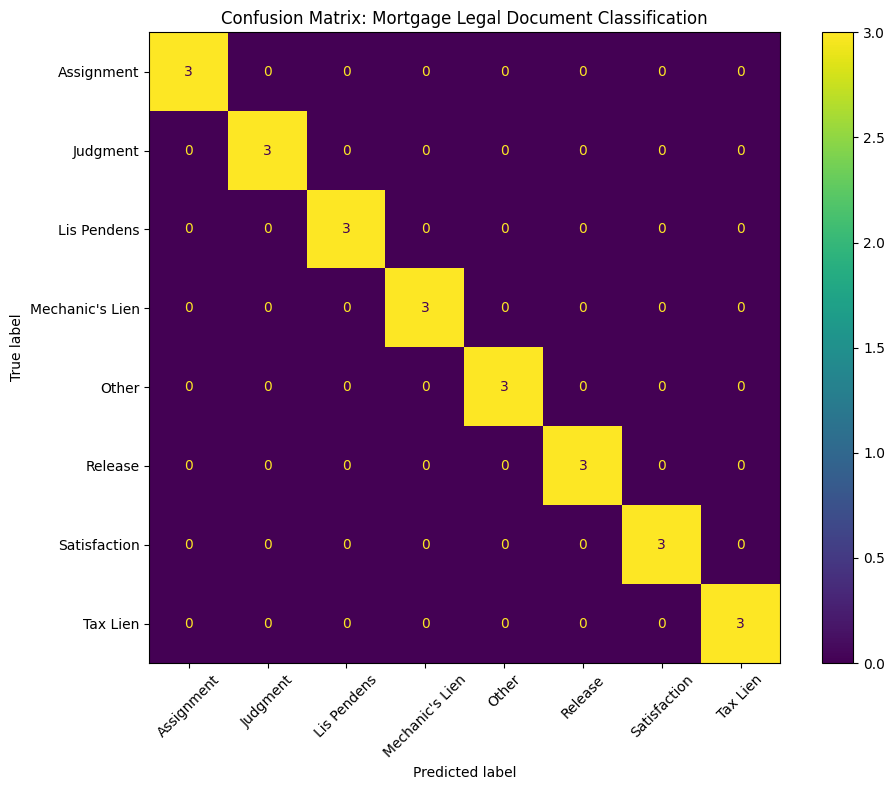

In [ ]:
# Create a confusion matrix to show correct and incorrect classifications

labels = sorted(df["actual_type"].unique())

confusion = confusion_matrix(
    y_test,
    predictions,
    labels=labels
)

figure, axis = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=labels
)

display.plot(
    ax=axis,
    xticks_rotation=45,
    values_format="d"
)

axis.set_title(
    "Confusion Matrix: Mortgage Legal Document Classification"
)

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

Every test document appears on the diagonal of the confusion matrix, confirming that all 24 records were classified correctly.

In a real mortgage servicing environment, categories such as judgments, satisfactions, tax liens, and releases may contain overlapping language. Additional training data and human review would be needed to manage those more difficult cases.

## 9. Extracting Key Document Information

After classification, the prototype uses regular expressions to identify selected business fields:

- Dollar amounts
- Recording dates
- Property addresses

This step demonstrates how the system can do more than label a document. It can also organize important information into a standardized format for analyst review.

In [ ]:
# These functions extract selected business information from each document.

def extract_amount(text):
    """
    Extract a dollar amount from the document.
    """

    amount_match = re.search(
        r"\$\d{1,3}(?:,\d{3})*(?:\.\d{2})?",
        text
    )

    if amount_match:
        return amount_match.group(0)

    return "Not stated"


def extract_date(text):
    """
    Extract a written recording date from the document.
    """

    months = (
        "January|February|March|April|May|June|July|August|"
        "September|October|November|December"
    )

    date_match = re.search(
        rf"\b(?:{months})\s+\d{{1,2}},\s+\d{{4}}\b",
        text
    )

    if date_match:
        return date_match.group(0)

    return "Not stated"


def extract_address(text):
    """
    Extract a simulated New Jersey property address.
    """

    address_match = re.search(
        r"\b\d{1,5}\s+[A-Za-z ]+\s"
        r"(?:Street|Avenue|Lane|Road),\s+"
        r"[A-Za-z ]+,\s+NJ\s+\d{5}\b",
        text
    )

    if address_match:
        return address_match.group(0)

    return "Not stated"


print("Information-extraction functions created.")

Information-extraction functions created.


## 10. Generating a Business Summary

The summary function combines the following information:

- Predicted document category
- Confidence score
- Recording date
- Property address
- Dollar amount, when available
- Potential mortgage-servicing impact

The summary is designed as a first draft only. Every output includes a statement that human verification is required.

In [ ]:
# Generate a concise business summary for each classified document.

def create_business_summary(
    document_text,
    predicted_type,
    confidence_score
):
    """
    Create a short business-oriented summary.
    """

    amount = extract_amount(document_text)
    recording_date = extract_date(document_text)
    property_address = extract_address(document_text)

    servicing_impact = {
        "Mechanic's Lien":
            "may create a title or payoff issue until resolved or released",

        "Lis Pendens":
            "signals pending litigation that may affect title or foreclosure activity",

        "Judgment":
            "may attach to the debtor's real property and require further title review",

        "Tax Lien":
            "may create a priority, payoff, or compliance concern",

        "Release":
            "indicates that a previously recorded lien has been discharged",

        "Satisfaction":
            "indicates that a previously recorded judgment has been paid or satisfied",

        "Assignment":
            "documents a transfer of mortgage or related servicing rights",

        "Other":
            "requires analyst review to determine servicing relevance"
    }

    summary = (
        f"Classified as {predicted_type} with "
        f"{confidence_score:.1%} model confidence. "
        f"Recording date: {recording_date}. "
        f"Property: {property_address}. "
    )

    if amount != "Not stated":
        summary += f"Referenced amount: {amount}. "

    summary += (
        f"Potential servicing impact: "
        f"{servicing_impact[predicted_type]}. "
        f"Human verification is required."
    )

    return summary


print("Business-summary function created.")

Business-summary function created.


## 11. Reviewing the Final Model Results

This section combines the original document text, actual category, predicted category, confidence score, classification result, and business summary into one table.

The table makes the model's output easier for analysts and managers to review.

In [ ]:
# Create a results table containing actual labels, predictions,
# confidence scores, and automated summaries.

results = pd.DataFrame({
    "document_id": id_test.values,
    "document_text": X_test.values,
    "actual_type": y_test.values,
    "predicted_type": predictions,
    "confidence": confidence_scores
})

# Determine whether each prediction was correct
results["correct"] = (
    results["actual_type"] == results["predicted_type"]
)

# Generate an automated summary for every document
results["business_summary"] = results.apply(
    lambda row: create_business_summary(
        row["document_text"],
        row["predicted_type"],
        row["confidence"]
    ),
    axis=1
)

results.head()

,document_id,document_text,actual_type,predicted_type,confidence,correct,business_summary
0,DOC-045,MUNICIPAL TAX LIEN for delinquent real estate ...,Tax Lien,Tax Lien,0.320474,True,Classified as Tax Lien with 32.0% model confid...
1,DOC-076,ASSIGNMENT OF MORTGAGE. First National Bank as...,Assignment,Assignment,0.368917,True,Classified as Assignment with 36.9% model conf...
2,DOC-088,"QUITCLAIM DEED executed April 21, 2026 conveyi...",Other,Other,0.240782,True,Classified as Other with 24.1% model confidenc...
3,DOC-022,NOTICE OF PENDENCY OF ACTION (LIS PENDENS). Pl...,Lis Pendens,Lis Pendens,0.348694,True,Classified as Lis Pendens with 34.9% model con...
4,DOC-036,"CIVIL JUDGMENT filed May 30, 2026. Creditor At...",Judgment,Judgment,0.243592,True,Classified as Judgment with 24.4% model confid...


In [ ]:
# Display selected fields in a cleaner format

display_results = results[
    [
        "document_id",
        "actual_type",
        "predicted_type",
        "confidence",
        "correct",
        "business_summary"
    ]
].copy()

display_results["confidence"] = (
    display_results["confidence"]
    .map(lambda value: f"{value:.1%}")
)

display_results.head(12)

,document_id,actual_type,predicted_type,confidence,correct,business_summary
0,DOC-045,Tax Lien,Tax Lien,32.0%,True,Classified as Tax Lien with 32.0% model confid...
1,DOC-076,Assignment,Assignment,36.9%,True,Classified as Assignment with 36.9% model conf...
2,DOC-088,Other,Other,24.1%,True,Classified as Other with 24.1% model confidenc...
3,DOC-022,Lis Pendens,Lis Pendens,34.9%,True,Classified as Lis Pendens with 34.9% model con...
4,DOC-036,Judgment,Judgment,24.4%,True,Classified as Judgment with 24.4% model confid...
5,DOC-056,Release,Release,38.8%,True,Classified as Release with 38.8% model confide...
6,DOC-004,Mechanic's Lien,Mechanic's Lien,20.2%,True,Classified as Mechanic's Lien with 20.2% model...
7,DOC-044,Tax Lien,Tax Lien,39.3%,True,Classified as Tax Lien with 39.3% model confid...
8,DOC-066,Satisfaction,Satisfaction,37.7%,True,Classified as Satisfaction with 37.7% model co...
9,DOC-079,Assignment,Assignment,30.1%,True,Classified as Assignment with 30.1% model conf...


### Results Table Interpretation

The results table shows that the predicted categories match the actual categories for the simulated test records.

The confidence score indicates how certain the model was about each prediction. In a production system, lower-confidence cases should be routed to an experienced analyst rather than processed automatically.

## 12. Human Review and Confidence Threshold

The prototype uses a 60% confidence threshold. A document is added to the review queue if:

- The prediction is incorrect, or
- The confidence score is below 60%.

This human-in-the-loop design helps prevent uncertain AI outputs from directly influencing legal, title, compliance, or servicing decisions.

In [ ]:
# Establish a confidence threshold for analyst review.
# Any result below 60% confidence should receive additional review.

REVIEW_THRESHOLD = 0.60

results["review_required"] = (
    (results["confidence"] < REVIEW_THRESHOLD)
    | (results["correct"] == False)
)

review_queue = results.loc[
    results["review_required"],
    [
        "document_id",
        "actual_type",
        "predicted_type",
        "confidence",
        "document_text"
    ]
].sort_values("confidence")

print("Documents tested:", len(results))
print("Correct classifications:", results["correct"].sum())
print(f"Overall accuracy: {results['correct'].mean():.1%}")
print("Documents requiring additional review:", len(review_queue))

review_queue

Documents tested: 24
Correct classifications: 24
Overall accuracy: 100.0%
Documents requiring additional review: 24


,document_id,actual_type,predicted_type,confidence,document_text
11,DOC-027,Judgment,Judgment,0.182053,"CIVIL JUDGMENT filed March 3, 2026. Creditor F..."
6,DOC-004,Mechanic's Lien,Mechanic's Lien,0.202306,NOTICE OF MECHANIC'S LIEN. United States Treas...
18,DOC-018,Lis Pendens,Lis Pendens,0.218056,NOTICE OF PENDENCY concerning foreclosure liti...
2,DOC-088,Other,Other,0.240782,"QUITCLAIM DEED executed April 21, 2026 conveyi..."
13,DOC-093,Other,Other,0.242314,PROPERTY RECORDING COVER SHEET for instrument ...
4,DOC-036,Judgment,Judgment,0.243592,"CIVIL JUDGMENT filed May 30, 2026. Creditor At..."
19,DOC-007,Mechanic's Lien,Mechanic's Lien,0.244785,NOTICE OF MECHANIC'S LIEN. First National Bank...
17,DOC-080,Assignment,Assignment,0.246570,"MORTGAGE ASSIGNMENT recorded February 14, 2026..."
15,DOC-024,Lis Pendens,Lis Pendens,0.249331,NOTICE OF PENDENCY concerning foreclosure liti...
12,DOC-051,Release,Release,0.260145,DISCHARGE AND RELEASE OF RECORDED LIEN dated M...


### Review Queue Interpretation

The simulated test set did not produce any low-confidence or incorrect predictions, so no documents were added to the review queue.

A production model would almost certainly produce uncertain cases. Those records should be reviewed manually, and analyst corrections should be used to improve the model over time.

## 13. Estimating Potential Business Value

This section estimates the possible operational benefit of AI-assisted review.

The calculation uses the following assumptions:

- 2,500 documents reviewed per month
- Six minutes for a fully manual first review
- 2.5 minutes for an AI-assisted first review

These values are illustrative and should be confirmed through an actual workplace time study.

In [ ]:
# Estimate possible business time savings.
#
# These figures are illustrative assumptions:
# Manual first review: 6 minutes per document
# AI-assisted first review: 2.5 minutes per document

manual_minutes_per_document = 6.0
ai_assisted_minutes_per_document = 2.5
monthly_document_volume = 2500

manual_review_hours = (
    monthly_document_volume
    * manual_minutes_per_document
    / 60
)

ai_assisted_review_hours = (
    monthly_document_volume
    * ai_assisted_minutes_per_document
    / 60
)

estimated_hours_saved = (
    manual_review_hours
    - ai_assisted_review_hours
)

estimated_time_reduction = (
    1
    - (
        ai_assisted_review_hours
        / manual_review_hours
    )
)

business_metrics = pd.DataFrame({
    "Metric": [
        "Monthly documents",
        "Manual review hours",
        "AI-assisted review hours",
        "Estimated hours saved",
        "Estimated review-time reduction"
    ],

    "Value": [
        f"{monthly_document_volume:,}",
        f"{manual_review_hours:,.1f}",
        f"{ai_assisted_review_hours:,.1f}",
        f"{estimated_hours_saved:,.1f}",
        f"{estimated_time_reduction:.1%}"
    ]
})

business_metrics

,Metric,Value
0,Monthly documents,"2,500"
1,Manual review hours,250.0
2,AI-assisted review hours,104.2
3,Estimated hours saved,145.8
4,Estimated review-time reduction,58.3%


### Business Impact Interpretation

Under the stated assumptions, AI-assisted review could reduce monthly review time from approximately 250 hours to 104.2 hours.

This represents an estimated savings of 145.8 hours per month, or a 58.3% reduction in first-review time. The saved time could allow analysts to focus on complex exceptions, quality assurance, compliance review, and customer-related issues.

## 14. Testing the Model with a New Document

This section demonstrates how the trained model handles a new simulated legal document that was not part of the original dataset.

The model predicts the document category, calculates a confidence score, extracts key fields, and produces a business summary.

In [ ]:
# Test the trained model with a new simulated legal document

new_document = """
NOTICE OF MECHANIC'S LIEN.
Garden State Roofing LLC claims a lien in the amount of $15,800.00
for roofing services completed at 337 Berkley Avenue,
Palmyra, NJ 08065. Owner: Sample Property Owner.
Recorded on July 10, 2026.
"""

new_prediction = model.predict([new_document])[0]

new_probabilities = model.predict_proba(
    [new_document]
)[0]

new_confidence = new_probabilities.max()

new_summary = create_business_summary(
    new_document,
    new_prediction,
    new_confidence
)

print("Predicted document type:", new_prediction)
print(f"Model confidence: {new_confidence:.1%}")
print()
print("Business summary:")
print(new_summary)

Predicted document type: Mechanic's Lien
Model confidence: 22.9%

Business summary:
Classified as Mechanic's Lien with 22.9% model confidence. Recording date: July 10, 2026. Property: 337 Berkley Avenue,
Palmyra, NJ 08065. Referenced amount: $15,800.00. Potential servicing impact: may create a title or payoff issue until resolved or released. Human verification is required.


### New Document Interpretation

The model identified the new record as a mechanic's lien because the document contains terms associated with unpaid labor, materials, contractors, lien amounts, and property information.

This example demonstrates how the model could support a mortgage servicing analyst by providing a standardized first review. The analyst would still verify the source document before taking action.

## 15. Exporting the Results

After evaluating the model, the complete set of predictions is exported to a CSV file. This file contains the document ID, actual document type, predicted document type, confidence score, classification result, and the AI-generated business summary.

Exporting the results makes it easier for analysts and managers to review the model's performance outside of Python. The CSV file could also be shared with stakeholders or used for additional quality assurance and reporting.

In [ ]:
# Save the detailed results as a CSV file

results.to_csv(
    "mortgage_legal_document_results.csv",
    index=False
)

print(
    "The results were saved as "
    "'mortgage_legal_document_results.csv'."
)

The results were saved as 'mortgage_legal_document_results.csv'.


### Export Interpretation

The CSV file was successfully created. This file provides a complete record of the model's predictions and can be used for auditing, reporting, or further business analysis. In a production environment, these results could be integrated into a mortgage servicing workflow or document management system.

## 16. Saving the Project Metrics

The final step is to save the overall performance metrics in a JSON file. The JSON file stores key evaluation results, including model accuracy, the number of correctly classified documents, the review queue count, and the estimated monthly time savings.

Saving these metrics provides a simple way to document the project's overall performance and makes the results easier to reuse in future reporting or dashboard applications.

In [ ]:
# Save the major project metrics in a JSON file

project_metrics = {
    "accuracy": float(accuracy),
    "test_documents": int(len(results)),
    "correct_classifications": int(
        results["correct"].sum()
    ),
    "review_queue_count": int(
        len(review_queue)
    ),
    "estimated_monthly_hours_saved": float(
        estimated_hours_saved
    ),
    "estimated_time_reduction": float(
        estimated_time_reduction
    )
}

with open(
    "mortgage_legal_document_metrics.json",
    "w"
) as metrics_file:

    json.dump(
        project_metrics,
        metrics_file,
        indent=2
    )

print("Project metrics saved successfully.")
print(json.dumps(project_metrics, indent=2))

Project metrics saved successfully.
{
  "accuracy": 1.0,
  "test_documents": 24,
  "correct_classifications": 24,
  "review_queue_count": 24,
  "estimated_monthly_hours_saved": 145.83333333333331,
  "estimated_time_reduction": 0.5833333333333333
}


### Final Project Interpretation

The project metrics confirm that the prototype successfully classified all 24 test documents in the simulated dataset, resulting in an overall accuracy of 100%.

While these results are encouraging, they reflect performance on a structured simulated dataset rather than real mortgage servicing documents. In practice, additional testing with de-identified production data would be required before deploying the model in a business environment. Overall, this project demonstrates that Natural Language Processing and machine learning can improve the efficiency of legal document classification while maintaining human oversight for important servicing decisions.

# References

Fannie Mae. (2026). *Governance framework on the use of artificial intelligence and machine learning.* https://singlefamily.fanniemae.com/

IBM. (n.d.). *What is natural language processing (NLP)?* https://www.ibm.com/think/topics/natural-language-processing

Microsoft. (n.d.). *What are large language models (LLMs)?* https://azure.microsoft.com/

Taulli, T. (2019). *Artificial Intelligence Basics: A Non-Technical Introduction.* Apress.